# Market (S&P 500 daily closes): the edge that was too easy

*Notebook journey for section 3. Every number the chapter uses is produced here, and every data figure is drawn here from the real prices. Part a is where we read one column of prices and turn it into a task we can actually learn, one transform at a time.*

## a. Reading the problem

all we have: 6664 daily closing prices, a single column in date order
first six closes: [1455.22, 1399.42, 1402.11, 1403.45, 1441.47, 1457.6]
the price wanders from 677 to 7610 over the years

trace, one day at a time:
  day 1: close 1399.42  ->  moved -3.83%  ->  size 3.83%
  day 2: close 1402.11  ->  moved +0.19%  ->  size 0.19%
  day 3: close 1403.45  ->  moved +0.10%  ->  size 0.10%
  day 4: close 1441.47  ->  moved +2.71%  ->  size 2.71%
  day 5: close 1457.60  ->  moved +1.12%  ->  size 1.12%

'usual' move size (the middle day): 0.54%   -> the busy / calm line
one row X[0] = the five sizes: ['3.83%', '0.19%', '0.10%', '2.71%', '1.12%']
        its answer = is tomorrow busier than usual? -> busy

rows: 6658   busy share: 0.500  (so a blind guess scores 0.5, a coin)


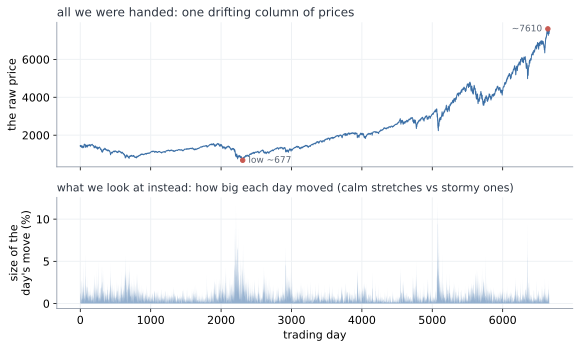

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import numpy as np, os
import matplotlib.pyplot as plt

# --- house style (kept identical across every chapter's figures) ---
ACCENT, MUTED, RED, GRID = "#3a6ea5", "#b8c0cc", "#c85a52", "#eef1f4"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.edgecolor": "#8a94a3", "axes.linewidth": 0.8})
def clean(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(True, color=GRID, linewidth=1); ax.set_axisbelow(True)

FIG  = "figures" if os.path.isdir("figures") else "../figures"
DATA = "data/gspc_2026-07-03.csv" if os.path.exists("data/gspc_2026-07-03.csv") else "../data/gspc_2026-07-03.csv"

# --- all we were handed: ONE column of daily closing prices, in date order ---
close = np.loadtxt(DATA, skiprows=1)
print("all we have:", len(close), "daily closing prices, a single column in date order")
print("first six closes:", [round(float(v), 2) for v in close[:6]])
print("the price wanders from", round(float(close.min())), "to", round(float(close.max())), "over the years")

# --- turn each raw price into how much it MOVED, then the SIZE of that move ---
r = np.diff(close) / close[:-1]     # the daily move, as a fraction (a percent)
s = np.abs(r)                       # the SIZE of the move, forgetting up or down
print("\ntrace, one day at a time:")
for t in range(1, 6):
    print(f"  day {t}: close {close[t]:.2f}  ->  moved {r[t-1]*100:+.2f}%  ->  size {s[t-1]*100:.2f}%")

# --- the task: from the last 5 sizes, is TOMORROW a busy day (bigger than usual)? ---
L = 5
X = np.column_stack([s[i:len(s) - L + i] for i in range(L)])
fut = s[L:]; X = X[:len(fut)]
usual = float(np.median(s))                 # "usual" = the middle day; half above, half below
y = (fut > usual).astype(int)
print(f"\n'usual' move size (the middle day): {usual*100:.2f}%   -> the busy / calm line")
print("one row X[0] = the five sizes:", [f"{v*100:.2f}%" for v in X[0]])
print("        its answer = is tomorrow busier than usual? ->", "busy" if y[0] else "calm")
print(f"\nrows: {len(y)}   busy share: {y.mean():.3f}  (so a blind guess scores 0.5, a coin)")

# ---------------- FIGURE 1: all we have (price) -> what we look at (size) ----------------
fig, (axp, axs) = plt.subplots(2, 1, figsize=(8.2, 5.0), sharex=True,
                               gridspec_kw={"height_ratios": [1.3, 1.0]})
day = np.arange(len(close))
axp.plot(day, close, color=ACCENT, linewidth=1.0)
axp.scatter([int(close.argmin()), int(close.argmax())], [close.min(), close.max()],
            color=RED, s=20, zorder=5)
axp.text(int(close.argmin()), close.min(), f"  low ~{round(float(close.min()))}",
         va="center", ha="left", fontsize=9, color="#5a6472")
axp.text(int(close.argmax()), close.max(), f"~{round(float(close.max()))}  ",
         va="center", ha="right", fontsize=9, color="#5a6472")
axp.set_ylabel("the raw price"); clean(axp)
axp.set_title("all we were handed: one drifting column of prices",
              loc="left", fontsize=12, color="#2b333f")

axs.fill_between(day[1:], s * 100, color=ACCENT, alpha=0.55, linewidth=0)
axs.set_ylabel("size of the\nday's move (%)"); axs.set_xlabel("trading day")
clean(axs)
axs.set_title("what we look at instead: how big each day moved (calm stretches vs stormy ones)",
              loc="left", fontsize=11, color="#2b333f")
fig.tight_layout()
fig.savefig(f"{FIG}/market_data.svg", bbox_inches="tight"); plt.show()


### Before we trust any score: is there a real pattern here at all?

Loan taught us not to celebrate a number before we know what stands behind it. So before we build anything, we ask one plain question: do big days actually tend to sit next to big days, or would we just be chasing noise? We put every day's size against the very next day's size, and look.

link between today's size and tomorrow's size: 0.287   (0 would mean no pattern at all)


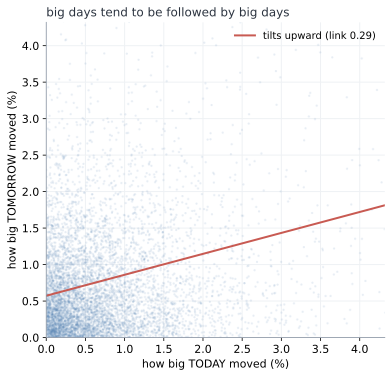

In [2]:
# --- the evidence we demand FIRST: does today's size predict tomorrow's? ---
today, tomorrow = s[:-1] * 100, s[1:] * 100
echo = float(np.corrcoef(s[:-1], s[1:])[0, 1])
print(f"link between today's size and tomorrow's size: {echo:.3f}   (0 would mean no pattern at all)")

cap = float(np.percentile(s, 99) * 100)      # trim the few most extreme days so the cloud is visible
fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.scatter(today, tomorrow, s=5, alpha=0.12, color=ACCENT, edgecolors="none", rasterized=True)
b1, b0 = np.polyfit(today, tomorrow, 1)       # a straight line through the cloud shows the tilt
xs = np.linspace(0, cap, 50)
ax.plot(xs, b0 + b1 * xs, color=RED, linewidth=2.0, label=f"tilts upward (link {echo:.2f})")
ax.set_xlim(0, cap); ax.set_ylim(0, cap)
ax.set_xlabel("how big TODAY moved (%)"); ax.set_ylabel("how big TOMORROW moved (%)")
ax.set_title("big days tend to be followed by big days", loc="left", fontsize=12, color="#2b333f")
ax.legend(loc="upper right", frameon=False, fontsize=10)
clean(ax)
fig.tight_layout()
fig.savefig(f"{FIG}/market_signal.svg", bbox_inches="tight", dpi=150); plt.show()   # rasterized dots -> small file
